# Sprint 4 — Modelo Baseline y Tracking con MLflow
## Proyecto: Productividad Asesores de Negocios

---

### Objetivo del sprint

Entrenar el modelo baseline (Logistic Regression multinomial) y registrar
el experimento en MLflow. Este sprint establece el **piso de métricas**
contra el cual se compararán LightGBM y XGBoost en el Sprint 5.

### ¿Por qué Logistic Regression como baseline?

- Es el modelo más simple posible para clasificación multiclase
- Sus coeficientes son interpretables directamente
- Si LightGBM no supera significativamente a LR, el problema no justifica
  la complejidad adicional
- Requiere el escalado del Sprint 3 — valida que el pipeline funciona

### ⚠️ Advertencia metodológica

> Si el baseline supera macro F1 > 0.70, revisar si hay leakage no detectado.
> Un baseline excesivamente bueno en un problema desbalanceado es señal de alarma.


## 1. Configuración y carga de datos procesados

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import joblib
import mlflow
import mlflow.sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, cohen_kappa_score,
    roc_auc_score, accuracy_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

PROCESSED  = Path('../data/processed')
FIG_DIR    = Path('../reports/figures')
MLRUNS_DIR = Path('../mlruns')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Cargar datos procesados del Sprint 3
data = np.load(PROCESSED / 'features_processed.npz', allow_pickle=True)
X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']
feature_names = data['feature_names']

# Cargar encoders
label_encoder = joblib.load(PROCESSED / 'label_encoder.joblib')
CLASS_NAMES   = list(label_encoder.classes_)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'Clases : {CLASS_NAMES}')
print(f'y_train distribucion: {dict(zip(*np.unique(y_train, return_counts=True)))}')


X_train: (1603, 22)
X_test : (401, 22)
Clases : ['Q1_BAJO', 'Q2_MEDIO_BAJO', 'Q3_MEDIO_ALTO', 'Q4_ALTO']
y_train distribucion: {np.int64(0): np.int64(401), np.int64(1): np.int64(401), np.int64(2): np.int64(400), np.int64(3): np.int64(401)}


## 2. Funciones de evaluación

Centralizamos el cálculo de métricas para reutilizarlas en los Sprints 5 y 6.
La métrica principal es **macro F1** — trata todas las clases por igual
independientemente de su frecuencia.


In [2]:
def calcular_metricas(y_true, y_pred, y_prob, class_names):
    '''
    Calcula el conjunto completo de metricas de evaluacion.
    
    Metricas:
      - macro F1  : metrica principal (trata todas las clases igual)
      - Cohen Kappa: acuerdo corregido por azar
      - AUC OvR   : capacidad discriminativa multiclase
      - Accuracy  : reportado pero NO es la metrica de decision
    '''
    metricas = {
        'macro_f1'  : f1_score(y_true, y_pred, average='macro'),
        'kappa'     : cohen_kappa_score(y_true, y_pred),
        'auc_ovr'   : roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro'),
        'accuracy'  : accuracy_score(y_true, y_pred),
    }
    # F1 por clase
    f1_por_clase = f1_score(y_true, y_pred, average=None)
    for i, cls in enumerate(class_names):
        metricas[f'f1_{cls}'] = f1_por_clase[i]
    return metricas


def plot_confusion_matrix(y_true, y_pred, class_names, titulo, filepath):
    '''
    Genera y guarda la matriz de confusion normalizada por fila.
    Normalizada por fila = recall por clase (que fraccion de cada clase se clasifica correctamente).
    '''
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='.2f')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()
    return filepath


print('Funciones de evaluacion definidas.')


Funciones de evaluacion definidas.


## 3. Configuración de MLflow

MLflow registra todos los experimentos localmente en `mlruns/`.
Para explorar los resultados visualmente ejecuta en otra terminal:
```bash
uv run mlflow ui
```
Luego abre http://localhost:5000 en el navegador.


In [3]:
import os

# MLflow 3.x requiere backend SQLite (el file store fue deprecado)
DB_PATH_MLFLOW = Path('../mlruns/mlflow.db')
DB_PATH_MLFLOW.parent.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{DB_PATH_MLFLOW.resolve()}')
mlflow.set_experiment('advisor_risk_classification')

print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experimento activo  : advisor_risk_classification')
print(f'Para ver resultados : uv run mlflow ui --backend-store-uri sqlite:///{DB_PATH_MLFLOW.resolve()}')


MLflow tracking URI : sqlite:///C:\Users\Marin\Documents\PROYECTO ML_OPS\productividad-asesores-negocios\mlruns\mlflow.db
Experimento activo  : advisor_risk_classification
Para ver resultados : uv run mlflow ui --backend-store-uri sqlite:///C:\Users\Marin\Documents\PROYECTO ML_OPS\productividad-asesores-negocios\mlruns\mlflow.db


## 4. Validación cruzada estratificada

Con ~1,600 observaciones en train usamos **k-fold estratificado (k=5)**
en lugar de un único hold-out. Esto nos da:
- Estimación más robusta del desempeño real
- Medida de varianza entre folds (estabilidad del modelo)

Un modelo con F1 = 0.65 ± 0.15 entre folds es inestable
y no debe presentarse como resultado final.


In [4]:
# Logistic Regression con manejo de desbalance
# scikit-learn 1.5+ maneja multinomial automaticamente sin parametro multi_class
lr_model = LogisticRegression(
    class_weight='balanced',     # Compensar desbalance de clases
    max_iter=1000,               # Suficiente para convergencia
    random_state=42,
    solver='lbfgs',              # Eficiente para multinomial
    C=1.0,                       # Regularizacion por defecto (baseline)
)

# K-fold estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Ejecutando validacion cruzada (5 folds)...')


from sklearn.metrics import make_scorer, cohen_kappa_score

cv_results = cross_validate(
    lr_model, X_train, y_train,
    cv=cv,
    scoring={
        'macro_f1' : 'f1_macro',
        'kappa'    : make_scorer(cohen_kappa_score),
        'accuracy' : 'accuracy',
    },
    return_train_score=False,
    n_jobs=-1,
)

print('\n=== RESULTADOS VALIDACION CRUZADA — LOGISTIC REGRESSION ===')
print(f'  Macro F1  : {cv_results["test_macro_f1"].mean():.4f} +/- {cv_results["test_macro_f1"].std():.4f}')
print(f'  Kappa     : {cv_results["test_kappa"].mean():.4f} +/- {cv_results["test_kappa"].std():.4f}')
print(f'  Accuracy  : {cv_results["test_accuracy"].mean():.4f} +/- {cv_results["test_accuracy"].std():.4f}')
print(f'\n  F1 por fold: {cv_results["test_macro_f1"].round(4)}')

varianza_f1 = cv_results['test_macro_f1'].std()
if varianza_f1 > 0.05:
    print(f'\nADVERTENCIA: varianza alta entre folds ({varianza_f1:.4f}) — modelo inestable')
else:
    print(f'\nVarianza entre folds aceptable ({varianza_f1:.4f})')


Ejecutando validacion cruzada (5 folds)...

=== RESULTADOS VALIDACION CRUZADA — LOGISTIC REGRESSION ===
  Macro F1  : 0.5862 +/- 0.0162
  Kappa     : 0.4510 +/- 0.0206
  Accuracy  : 0.5883 +/- 0.0155

  F1 por fold: [0.602  0.6002 0.5689 0.5642 0.5955]

Varianza entre folds aceptable (0.0162)


## 5. Entrenamiento final y registro en MLflow

Entrenamos sobre el train completo (no sobre un fold) y evaluamos en test.
Todos los parámetros, métricas y artefactos quedan registrados en MLflow.


In [5]:
with mlflow.start_run(run_name='logistic_regression_baseline') as run:

    # Registrar parametros del modelo
    mlflow.log_params({
        'model_type'    : 'LogisticRegression',
        'multi_class'   : 'multinomial',
        'class_weight'  : 'balanced',
        'C'             : 1.0,
        'solver'        : 'lbfgs',
        'max_iter'      : 1000,
        'random_state'  : 42,
        'n_train'       : len(X_train),
        'n_test'        : len(X_test),
        'n_features'    : X_train.shape[1],
        'target'        : 'TARGET_B',
        'cv_folds'      : 5,
    })

    # Registrar metricas de CV
    mlflow.log_metrics({
        'cv_macro_f1_mean' : cv_results['test_macro_f1'].mean(),
        'cv_macro_f1_std'  : cv_results['test_macro_f1'].std(),
        'cv_kappa_mean'    : cv_results['test_kappa'].mean(),
        'cv_accuracy_mean' : cv_results['test_accuracy'].mean(),
    })

    # Entrenar sobre train completo
    lr_model.fit(X_train, y_train)

    # Predecir en test
    y_pred  = lr_model.predict(X_test)
    y_prob  = lr_model.predict_proba(X_test)

    # Calcular metricas en test
    metricas_test = calcular_metricas(y_test, y_pred, y_prob, CLASS_NAMES)

    # Registrar metricas de test en MLflow
    mlflow.log_metrics({f'test_{k}': v for k, v in metricas_test.items()})

    # Generar y guardar matriz de confusion
    cm_path = FIG_DIR / '04_confusion_matrix_lr_baseline.png'
    plot_confusion_matrix(
        y_test, y_pred, CLASS_NAMES,
        'Logistic Regression Baseline — Matriz de Confusion (normalizada)',
        cm_path,
    )
    mlflow.log_artifact(str(cm_path))

    # Registrar el modelo en MLflow
    mlflow.sklearn.log_model(lr_model, 'logistic_regression_baseline')

    run_id = run.info.run_id

print('=== METRICAS EN TEST — LOGISTIC REGRESSION BASELINE ===')
print(f'  Macro F1  : {metricas_test["macro_f1"]:.4f}  <- METRICA PRINCIPAL')
print(f'  Kappa     : {metricas_test["kappa"]:.4f}')
print(f'  AUC OvR   : {metricas_test["auc_ovr"]:.4f}')
print(f'  Accuracy  : {metricas_test["accuracy"]:.4f}  <- no es la metrica de decision')
print(f'\nF1 por clase:')
for cls in CLASS_NAMES:
    print(f'  {cls:<20}: {metricas_test[f"f1_{cls}"]:.4f}')
print(f'\nMLflow run_id: {run_id}')


2026/06/04 18:30:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 18:30:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/04 18:31:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


=== METRICAS EN TEST — LOGISTIC REGRESSION BASELINE ===
  Macro F1  : 0.5696  <- METRICA PRINCIPAL
  Kappa     : 0.4248
  AUC OvR   : 0.8079
  Accuracy  : 0.5686  <- no es la metrica de decision

F1 por clase:
  Q1_BAJO             : 0.6524
  Q2_MEDIO_BAJO       : 0.4645
  Q3_MEDIO_ALTO       : 0.4467
  Q4_ALTO             : 0.7150

MLflow run_id: 3eff338b0951403ca9fe71d63fe2757f


## 6. Reporte de clasificación detallado

=== CLASSIFICATION REPORT — LOGISTIC REGRESSION BASELINE ===
               precision    recall  f1-score   support

      Q1_BAJO     0.7011    0.6100    0.6524       100
Q2_MEDIO_BAJO     0.4414    0.4900    0.4645       100
Q3_MEDIO_ALTO     0.4583    0.4356    0.4467       101
      Q4_ALTO     0.6916    0.7400    0.7150       100

     accuracy                         0.5686       401
    macro avg     0.5731    0.5689    0.5696       401
 weighted avg     0.5728    0.5686    0.5693       401



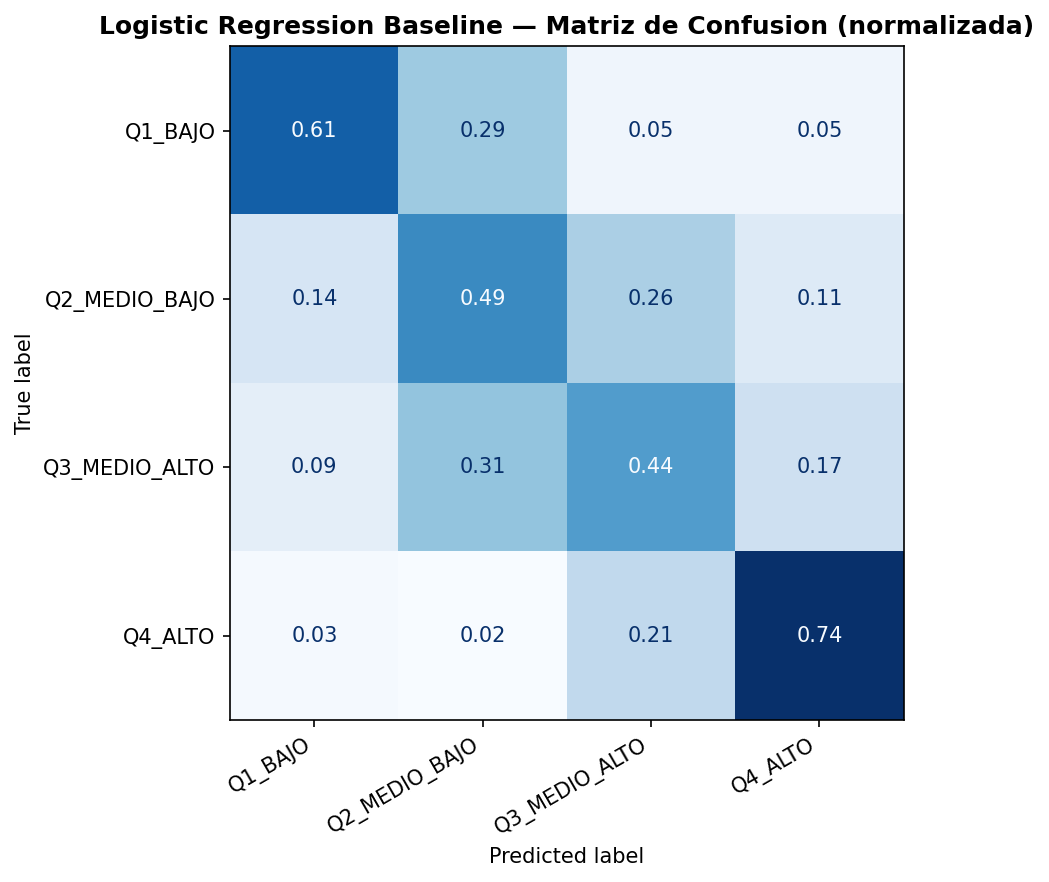

In [6]:
print('=== CLASSIFICATION REPORT — LOGISTIC REGRESSION BASELINE ===')
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
))

# Mostrar la imagen de la matriz de confusion
from IPython.display import Image, display as ipy_display
ipy_display(Image(filename=str(cm_path)))


## 7. Piso de métricas establecido

In [7]:
print('''
╔══════════════════════════════════════════════════════════════════╗
║         PISO DE METRICAS — LOGISTIC REGRESSION BASELINE        ║
║         Referencia para comparacion en Sprint 5                 ║
╠══════════════════════════════════════════════════════════════════╣
''')

print(f'  CV Macro F1 (5-fold) : {cv_results["test_macro_f1"].mean():.4f} +/- {cv_results["test_macro_f1"].std():.4f}')
print(f'  Test Macro F1        : {metricas_test["macro_f1"]:.4f}')
print(f'  Test Kappa           : {metricas_test["kappa"]:.4f}')
print(f'  Test AUC OvR         : {metricas_test["auc_ovr"]:.4f}')

print('''
  Para superar este baseline en Sprint 5, LightGBM debe mejorar
  el macro F1 de test en al menos 3 puntos porcentuales.
  Si no lo supera, documentar por que la complejidad adicional
  no se justifica.
╚══════════════════════════════════════════════════════════════════╝
''')



╔══════════════════════════════════════════════════════════════════╗
║         PISO DE METRICAS — LOGISTIC REGRESSION BASELINE        ║
║         Referencia para comparacion en Sprint 5                 ║
╠══════════════════════════════════════════════════════════════════╣

  CV Macro F1 (5-fold) : 0.5862 +/- 0.0162
  Test Macro F1        : 0.5696
  Test Kappa           : 0.4248
  Test AUC OvR         : 0.8079

  Para superar este baseline en Sprint 5, LightGBM debe mejorar
  el macro F1 de test en al menos 3 puntos porcentuales.
  Si no lo supera, documentar por que la complejidad adicional
  no se justifica.
╚══════════════════════════════════════════════════════════════════╝



In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

# Cargar dataset de asesores completo
df_asesores = pd.read_parquet('../data/interim/target_b_full.parquet')

# Correlacion entre TDNC y las features numericas
print("=== CORRELACION ENTRE TDNC Y FEATURES NUMERICAS ===\n")
num_cols = [
    'GRUPOS', 'CLIENTES', 'PRESTAMO', 'CLIENTES_PRESTAMO',
    'CARTERA_HOY', 'CARTERA_SEMANT', 'INCREMENTO_CARTERA',
    'ATRASO', 'TASA_PROM', 'PROVISION_HOY', 'PROVISION_SEMANT',
    'GASTO_PROVISION_SEMANAL', 'CLIENTES_NUEVOS',
    'DESEMBOLSO_CLIENTES_NUEVOS', 'N_SEMANAS_OBS', 'EDAD',
]

corr = df_asesores[num_cols + ['TDNC']].corr()['TDNC'].drop('TDNC')
corr_sorted = corr.abs().sort_values(ascending=False)
print(corr_sorted.to_string())

=== CORRELACION ENTRE TDNC Y FEATURES NUMERICAS ===

ATRASO                        0.850963
PROVISION_HOY                 0.820798
PROVISION_SEMANT              0.812788
GASTO_PROVISION_SEMANAL       0.376736
CLIENTES_PRESTAMO             0.349975
CARTERA_HOY                   0.342875
CARTERA_SEMANT                0.280013
PRESTAMO                      0.272457
CLIENTES_NUEVOS               0.222795
TASA_PROM                     0.198479
INCREMENTO_CARTERA            0.186487
DESEMBOLSO_CLIENTES_NUEVOS    0.098321
EDAD                          0.083239
GRUPOS                        0.036577
N_SEMANAS_OBS                 0.032428
CLIENTES                      0.020846
